# 📝 SO1-B — Classification de Texte Manipulateur avec RoBERTa
## Projet CBL — Media Credibility | Module : Manipulation des Médias

---

### 🎯 Objectif
Utiliser **RoBERTa (Meta/Facebook)** — le modèle gagnant de la comparaison SO1-B — pour classifier un texte comme **manipulateur (1)** ou **neutre (0)**.

### 🔗 Lien avec SO1-A
Dans SO1-A, **TrOCR** extrait le texte des images publicitaires. Ici, RoBERTa classifie ce texte pour détecter la manipulation.

### 🏆 Pourquoi RoBERTa ?
RoBERTa a obtenu **F1 = 0.9978** et un **Recall = 1.0** (aucun texte manipulateur raté) lors de la comparaison avec BERT et DistilBERT. Son entraînement sur 160 Go de texte (10× plus que BERT) lui confère une meilleure compréhension des patterns linguistiques de manipulation.

### 📋 Structure du notebook
1. **Exploration du dataset** — visualisations et analyse linguistique
2. **Entraînement RoBERTa** — fine-tuning sur Clickbait Dataset
3. **XAI** — 3 méthodes d'explicabilité
4. **Évaluation des performances** — métriques détaillées

---

## ⚙️ PARTIE 0 — Installation et Imports

In [1]:
!pip install transformers datasets scikit-learn captum shap matplotlib seaborn wordcloud -q
print('✅ Librairies installées !')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.7 MB/s eta 0:00:00ta 0:00:01
✅ Librairies installées !


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
import re
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report, matthews_corrcoef,
    roc_curve, precision_recall_curve, average_precision_score
)

# ── Configuration ────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Chemin dataset ───────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/amananandrai/clickbait-dataset/clickbait_data.csv'

print(f'✅ PyTorch  : {torch.__version__}')
print(f'✅ Device   : {device}')
if torch.cuda.is_available():
    print(f'✅ GPU      : {torch.cuda.get_device_name(0)}')
print(f'✅ Dataset  : {DATA_PATH}')

✅ PyTorch  : 2.10.0+cu128
✅ Device   : cuda
✅ GPU      : Tesla T4
✅ Dataset  : /kaggle/input/datasets/amananandrai/clickbait-dataset/clickbait_data.csv


---
# 📊 PARTIE 1 — Exploration du Dataset

Le **Clickbait Dataset (Webis 2017)** contient 32 000 titres d'articles labelisés :
- **Label 1** = Clickbait / Manipulateur
- **Label 0** = Neutre / Normal

Sources : WikiNews, NYT, The Guardian, BuzzFeed, Upworthy, ViralNova...

In [3]:
# ============================================================
# 1.1 — Chargement et statistiques globales
# ============================================================
df = pd.read_csv(DATA_PATH)
df.columns = ['headline', 'label']
df = df.dropna()
df = df[df['headline'].str.strip() != '']
df['label'] = df['label'].astype(int)

# Features textuelles
df['nb_mots']     = df['headline'].str.split().str.len()
df['nb_chars']    = df['headline'].str.len()
df['nb_majusc']   = df['headline'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['nb_exclam']   = df['headline'].str.count('!')
df['nb_interro']  = df['headline'].str.count(r'\?')
df['ratio_maj']   = df['nb_majusc'] / (df['nb_chars'] + 1)

print('='*60)
print('📊 STATISTIQUES GLOBALES — Clickbait Dataset')
print('='*60)
print(f'  Total exemples       : {len(df):,}')
print(f'  Manipulateurs (1)    : {sum(df.label==1):,} ({sum(df.label==1)/len(df)*100:.1f}%)')
print(f'  Neutres (0)          : {sum(df.label==0):,} ({sum(df.label==0)/len(df)*100:.1f}%)')
print(f'  Longueur moy (mots)  : {df.nb_mots.mean():.1f} ± {df.nb_mots.std():.1f}')
print(f'  Longueur moy (chars) : {df.nb_chars.mean():.1f} ± {df.nb_chars.std():.1f}')
print('='*60)
print('\n📋 Exemples MANIPULATEURS :')
for h in df[df.label==1]['headline'].sample(5, random_state=42).values:
    print(f'  🔴 {h}')
print('\n📋 Exemples NEUTRES :')
for h in df[df.label==0]['headline'].sample(5, random_state=42).values:
    print(f'  🟢 {h}')

📊 STATISTIQUES GLOBALES — Clickbait Dataset
  Total exemples       : 32,000
  Manipulateurs (1)    : 15,999 (50.0%)
  Neutres (0)          : 16,001 (50.0%)
  Longueur moy (mots)  : 9.1 ± 2.6
  Longueur moy (chars) : 53.8 ± 14.8

📋 Exemples MANIPULATEURS :
  🔴 Is This Celeb Danish, Norwegian, Or Swedish
  🔴 10 Go-Go Remakes You Absolutely Must Hear
  🔴 How Well Do You Know The Countries of Africa
  🔴 If You Thought Your Hotel Safe Was Secure, Think Again
  🔴 13 Beautifully Honest Valentine's Cards For People Who Are Single AF

📋 Exemples NEUTRES :
  🟢 Obama Team Makes Early Efforts to Show Willingness to Reach Out to Republicans
  🟢 Virgin Atlantic jet fire investigation finds faulty wiring in A340 fleet
  🟢 US State department official resigns after Wikileaks comments
  🟢 John Edwards endorses Barack Obama
  🟢 Apple introduces new iPod with video playback capabilities


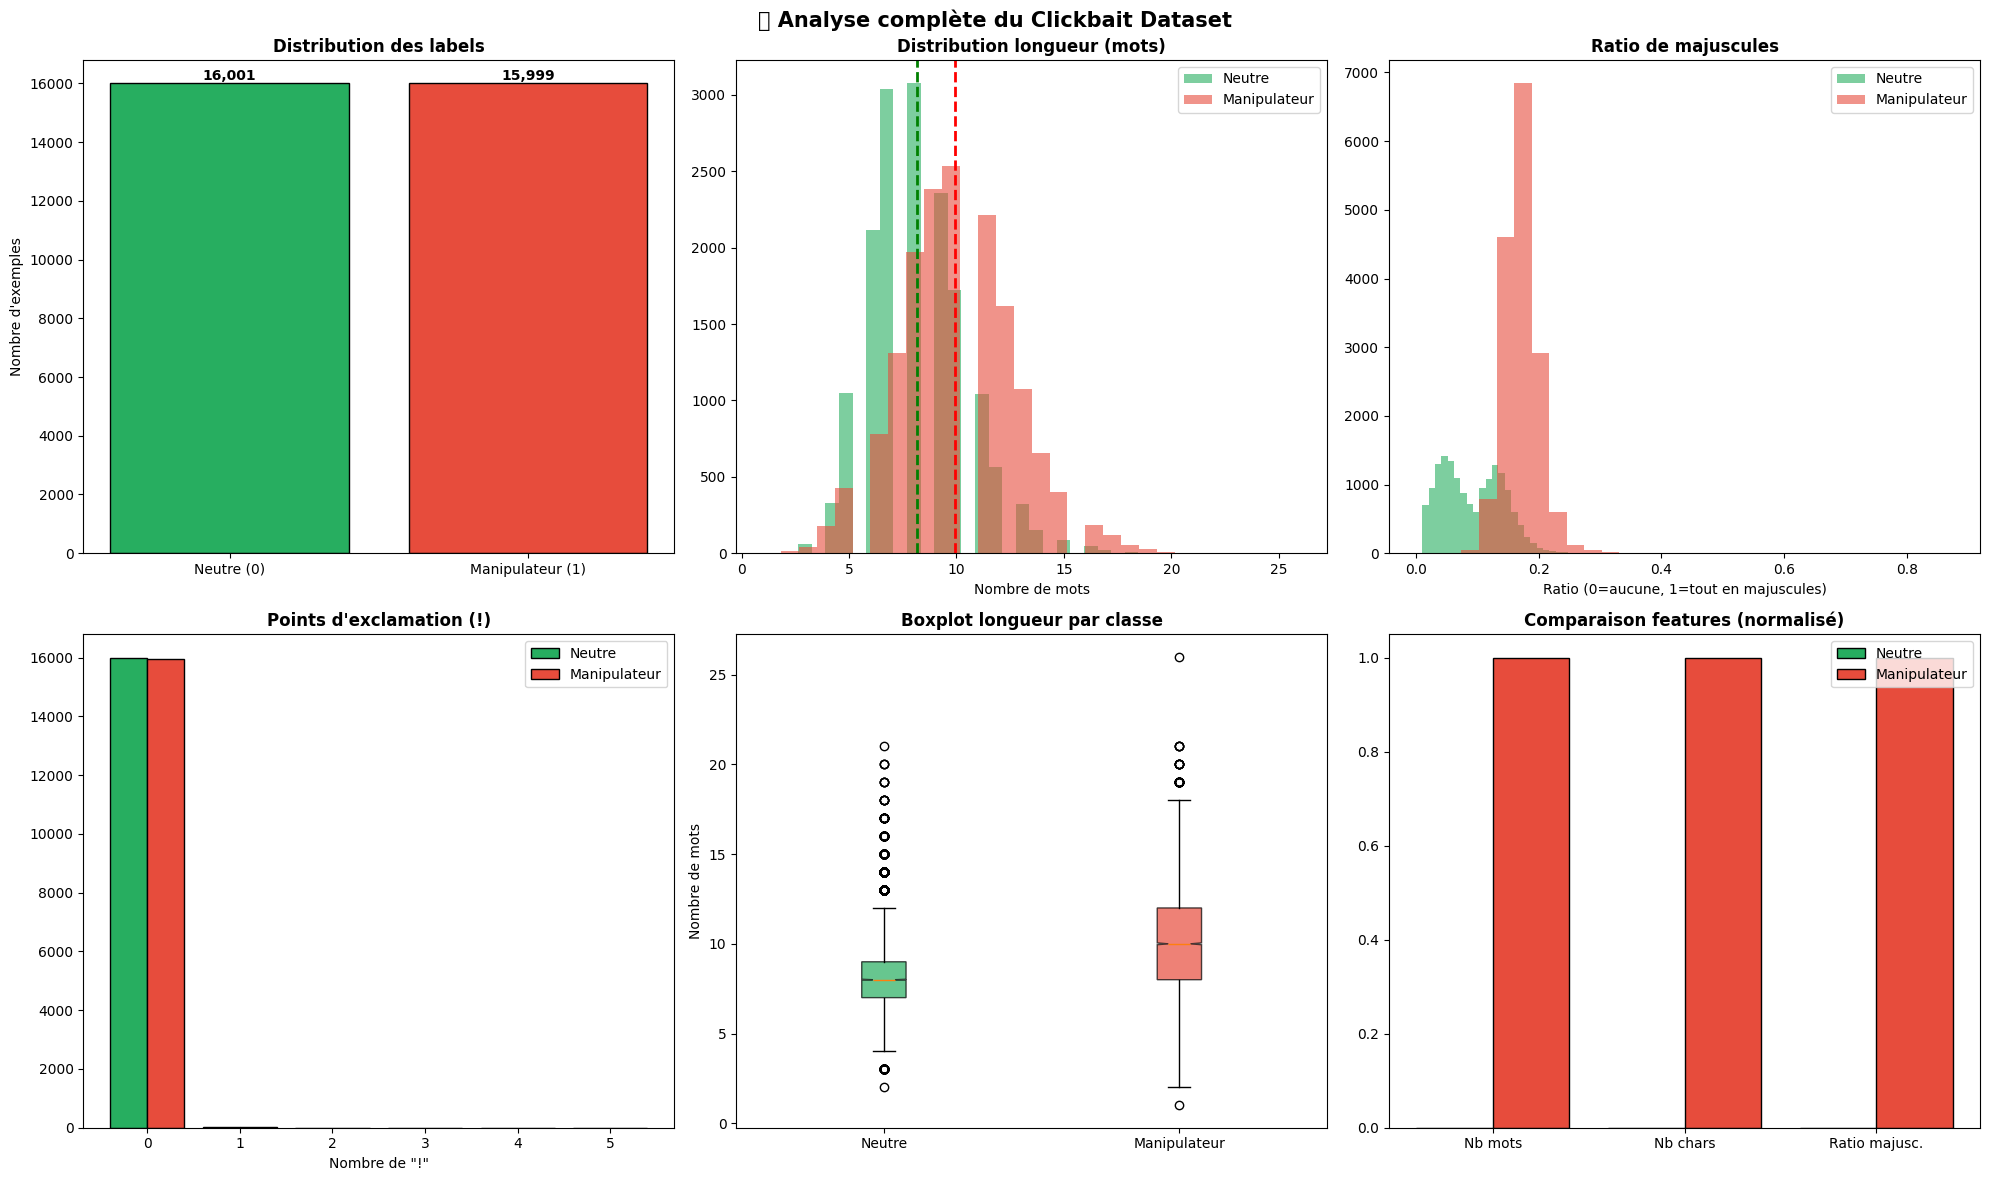

✅ Visualisations sauvegardées


In [4]:
# ============================================================
# 1.2 — Visualisations de la distribution du dataset
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Analyse complète du Clickbait Dataset', fontsize=15, fontweight='bold')

# ── Graphique 1 : Distribution des labels ────────────────────
counts = df.label.value_counts()
bars = axes[0][0].bar(['Neutre (0)', 'Manipulateur (1)'],
                       [counts[0], counts[1]],
                       color=['#27ae60', '#e74c3c'], edgecolor='black')
axes[0][0].set_title('Distribution des labels', fontweight='bold')
axes[0][0].set_ylabel('Nombre d\'exemples')
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0][0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                   f'{val:,}', ha='center', fontweight='bold')

# ── Graphique 2 : Distribution longueur (mots) ───────────────
axes[0][1].hist(df[df.label==0].nb_mots, bins=30, alpha=0.6, color='#27ae60', label='Neutre')
axes[0][1].hist(df[df.label==1].nb_mots, bins=30, alpha=0.6, color='#e74c3c', label='Manipulateur')
axes[0][1].axvline(df[df.label==0].nb_mots.mean(), color='green', linestyle='--', linewidth=2)
axes[0][1].axvline(df[df.label==1].nb_mots.mean(), color='red',   linestyle='--', linewidth=2)
axes[0][1].set_title('Distribution longueur (mots)', fontweight='bold')
axes[0][1].set_xlabel('Nombre de mots')
axes[0][1].legend()

# ── Graphique 3 : Ratio de majuscules ────────────────────────
axes[0][2].hist(df[df.label==0].ratio_maj, bins=30, alpha=0.6, color='#27ae60', label='Neutre')
axes[0][2].hist(df[df.label==1].ratio_maj, bins=30, alpha=0.6, color='#e74c3c', label='Manipulateur')
axes[0][2].set_title('Ratio de majuscules', fontweight='bold')
axes[0][2].set_xlabel('Ratio (0=aucune, 1=tout en majuscules)')
axes[0][2].legend()

# ── Graphique 4 : Nb de points d'exclamation ─────────────────
excl_neutre = df[df.label==0].nb_exclam.value_counts().sort_index().head(6)
excl_manip  = df[df.label==1].nb_exclam.value_counts().sort_index().head(6)
x = np.arange(6)
axes[1][0].bar(x - 0.2, excl_neutre.reindex(range(6), fill_value=0),
               0.4, color='#27ae60', label='Neutre', edgecolor='black')
axes[1][0].bar(x + 0.2, excl_manip.reindex(range(6), fill_value=0),
               0.4, color='#e74c3c', label='Manipulateur', edgecolor='black')
axes[1][0].set_title('Points d\'exclamation (!)', fontweight='bold')
axes[1][0].set_xlabel('Nombre de "!"')
axes[1][0].set_xticks(x)
axes[1][0].legend()

# ── Graphique 5 : Boxplot longueur par classe ─────────────────
data_box = [df[df.label==0].nb_mots.values, df[df.label==1].nb_mots.values]
bp = axes[1][1].boxplot(data_box, labels=['Neutre', 'Manipulateur'],
                         patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['#27ae60', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1][1].set_title('Boxplot longueur par classe', fontweight='bold')
axes[1][1].set_ylabel('Nombre de mots')

# ── Graphique 6 : Longueur moyenne par classe ─────────────────
stats = df.groupby('label')[['nb_mots', 'nb_chars', 'ratio_maj']].mean()
stats_norm = (stats - stats.min()) / (stats.max() - stats.min())
x6 = np.arange(3)
axes[1][2].bar(x6 - 0.2, stats_norm.loc[0].values, 0.4,
               color='#27ae60', label='Neutre', edgecolor='black')
axes[1][2].bar(x6 + 0.2, stats_norm.loc[1].values, 0.4,
               color='#e74c3c', label='Manipulateur', edgecolor='black')
axes[1][2].set_title('Comparaison features (normalisé)', fontweight='bold')
axes[1][2].set_xticks(x6)
axes[1][2].set_xticklabels(['Nb mots', 'Nb chars', 'Ratio majusc.'])
axes[1][2].legend()

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisations sauvegardées')

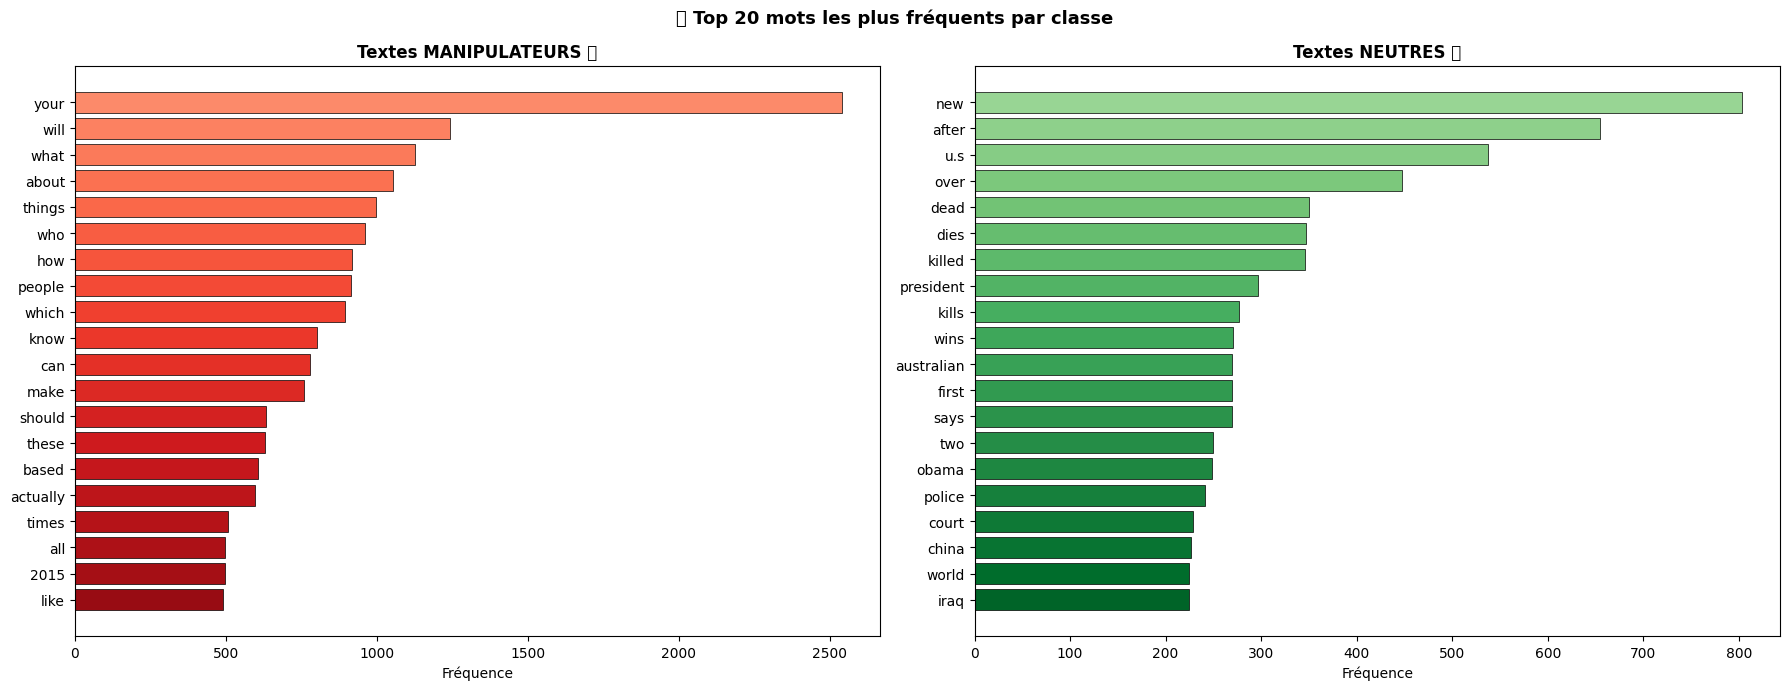

✅ Analyse des mots sauvegardée


In [5]:
# ============================================================
# 1.3 — Analyse des mots les plus fréquents par classe
# ============================================================
STOP_WORDS = {'the','a','an','in','of','to','and','is','for','on',
              'this','that','with','at','by','from','are','was','it',
              'be','as','or','its','not','have','he','she','we','you'}

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend([w.lower().strip('.,!?;:"\'-') for w in t.split()
                      if w.lower() not in STOP_WORDS and len(w) > 2])
    return Counter(words).most_common(n)

top_manip  = get_top_words(df[df.label==1]['headline'].values)
top_neutre = get_top_words(df[df.label==0]['headline'].values)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🔤 Top 20 mots les plus fréquents par classe', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], top_manip,  'Textes MANIPULATEURS 🔴', '#e74c3c'),
    (axes[1], top_neutre, 'Textes NEUTRES 🟢',        '#27ae60')
]:
    words, counts = zip(*data)
    colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(words))) if 'MANIP' in title \
                 else plt.cm.Greens(np.linspace(0.4, 0.9, len(words)))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=colors_bar[::-1], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Analyse des mots sauvegardée')

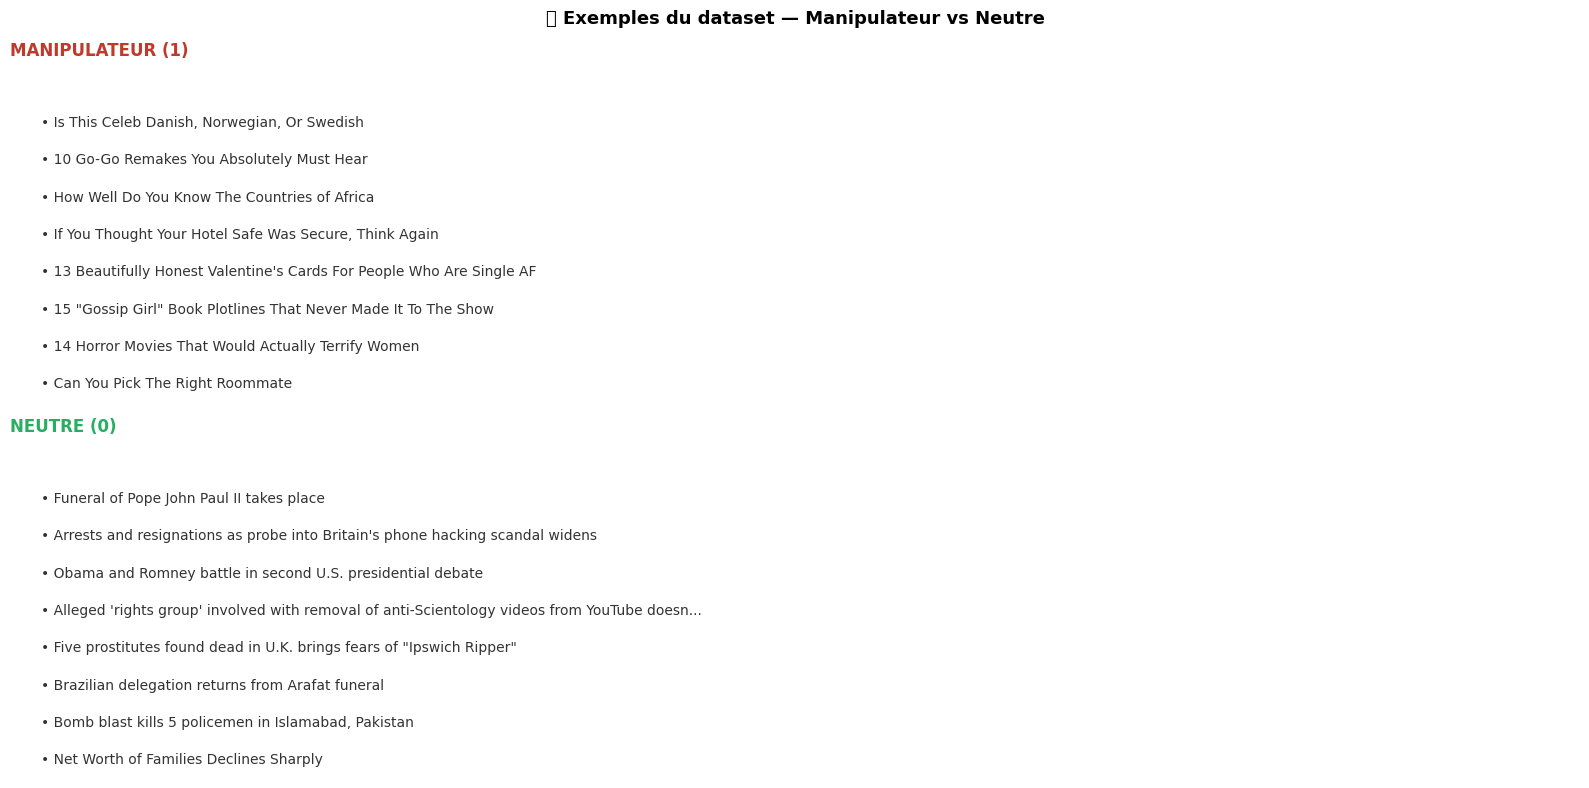

✅ Exemples sauvegardés


In [6]:
# ============================================================
# 1.4 — Exemples visuels du dataset (tableau illustratif)
# ============================================================
np.random.seed(42)
ex_manip  = df[df.label==1].sample(8)['headline'].values
ex_neutre = df[df.label==0].sample(8)['headline'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('📋 Exemples du dataset — Manipulateur vs Neutre', fontsize=13, fontweight='bold')

for ax, examples, label, color, bg in [
    (axes[0], ex_manip,  'MANIPULATEUR (1)', '#c0392b', '#fdf0ec'),
    (axes[1], ex_neutre, 'NEUTRE (0)',       '#27ae60', '#eaf5ee')
]:
    ax.set_facecolor(bg)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(examples) + 1)
    ax.axis('off')
    ax.set_title(label, fontsize=12, fontweight='bold', color=color, loc='left', pad=8)
    for i, ex in enumerate(examples):
        ex_short = ex[:90] + '...' if len(ex) > 90 else ex
        ax.text(0.2, len(examples) - i - 0.5, f'• {ex_short}',
                fontsize=10, va='center', color='#333333')

plt.tight_layout()
plt.savefig('exemples_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Exemples sauvegardés')

In [7]:
# ============================================================
# 1.5 — Préparation des données (Split train/val/test)
# ============================================================
# Sous-échantillonnage équilibré pour l'entraînement
df_manip  = df[df.label==1].sample(3000, random_state=42)
df_neutre = df[df.label==0].sample(3000, random_state=42)
df_sample = pd.concat([df_manip, df_neutre]).sample(frac=1, random_state=42).reset_index(drop=True)

texts  = df_sample['headline'].tolist()
labels = df_sample['label'].tolist()

# Split 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('✅ Split terminé !')
print(f'   Train      : {len(X_train)} exemples ({sum(y_train)} manip / {len(y_train)-sum(y_train)} neutres)')
print(f'   Validation : {len(X_val)} exemples')
print(f'   Test       : {len(X_test)} exemples')

✅ Split terminé !
   Train      : 4200 exemples (2100 manip / 2100 neutres)
   Validation : 900 exemples
   Test       : 900 exemples


---
# 🤖 PARTIE 2 — Modèle RoBERTa

## Architecture RoBERTa — Comment ça marche ?

```
Texte : "ABONNEZ-VOUS MAINTENANT avant que l'offre expire !!!"
         ↓
┌──────────────────────────────────────────────────────────┐
│  Tokenization BPE (Byte-Pair Encoding)                   │
│  → [CLS] ĠABON NEZ - VOUS ĠMAINTENANT ... [SEP]          │
│  → 50 000 tokens vocab (vs 30K pour BERT)               │
└──────────────────────────┬───────────────────────────────┘
                           ↓
┌──────────────────────────────────────────────────────────┐
│  12 couches Transformer Encoder                          │
│  • Multi-Head Self-Attention (12 têtes)                  │
│    → chaque mot regarde TOUS les autres mots             │
│    → "expire" regarde "offre" → comprend l'urgence       │
│  • Feed-Forward Network (768 → 3072 → 768)              │
│  • Dynamic Masking : masque différent à chaque époque   │
└──────────────────────────┬───────────────────────────────┘
                           ↓
┌──────────────────────────────────────────────────────────┐
│  Token [CLS] → résume toute la phrase                    │
│  Dense(768→2) + Sigmoid                                  │
└──────────────────────────┬───────────────────────────────┘
                           ↓
      MANIPULATEUR (0.97) ou NEUTRE (0.03)
```

**Différence clé vs BERT :** RoBERTa est entraîné sur 160 Go de texte (BERT : 16 Go) avec du **Dynamic Masking** — le masque change à chaque époque, forçant le modèle à généraliser mieux.

In [8]:
# ============================================================
# 2.1 — Classe Dataset PyTorch
# ============================================================
class ClickbaitDataset(Dataset):
    """
    Prépare les textes pour RoBERTa.
    La tokenization transforme le texte en IDs numériques :
    'SOLDES'  →  [0, 18102, 2, ...]
    Les inputs_ids + attention_mask sont les entrées du modèle.
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length    = self.max_length,
            padding       = 'max_length',
            truncation    = True,
            return_tensors= 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('✅ Classe ClickbaitDataset définie !')

✅ Classe ClickbaitDataset définie !


In [9]:
# ============================================================
# 2.2 — Chargement de RoBERTa
# ============================================================
print('⏳ Chargement de RoBERTa (roberta-base)...')

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model     = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=2
).to(device)

# Création des DataLoaders
ds_train = ClickbaitDataset(X_train, y_train, tokenizer)
ds_val   = ClickbaitDataset(X_val,   y_val,   tokenizer)
ds_test  = ClickbaitDataset(X_test,  y_test,  tokenizer)

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_val   = DataLoader(ds_val,   batch_size=32)
dl_test  = DataLoader(ds_test,  batch_size=32)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'\n✅ RoBERTa chargé sur {device} !')
print(f'   Paramètres totaux : {total_params:.1f}M')
print(f'   Train batches     : {len(dl_train)}')
print(f'   Val batches       : {len(dl_val)}')
print(f'   Test batches      : {len(dl_test)}')

⏳ Chargement de RoBERTa (roberta-base)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ RoBERTa chargé sur cuda !
   Paramètres totaux : 124.6M
   Train batches     : 263
   Val batches       : 29
   Test batches      : 29


In [10]:
# ============================================================
# 2.3 — Fonctions d'entraînement et d'évaluation
# ============================================================
def train_epoch(model, dataloader, optimizer, scheduler):
    """Entraîne le modèle pendant 1 époque."""
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch in tqdm(dataloader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels_batch)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.cpu().numpy())

    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)


def evaluate(model, dataloader):
    """Évalue le modèle sur un dataset."""
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='  Eval', leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels_batch)

            total_loss += outputs.loss.item()
            probs  = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            preds  = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_batch.cpu().numpy())
            all_probs.extend(probs)

    avg_loss  = total_loss / len(dataloader)
    acc       = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    auc       = roc_auc_score(all_labels, all_probs)
    mcc       = matthews_corrcoef(all_labels, all_preds)

    return avg_loss, acc, f1, precision, recall, auc, mcc, all_preds, all_labels, all_probs

print('✅ Fonctions définies !')

✅ Fonctions définies !


In [11]:
# ============================================================
# 2.4 — Entraînement RoBERTa (3 époques)
# ============================================================
EPOCHS   = 3
LR       = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(dl_train) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = total_steps // 10,
    num_training_steps= total_steps
)

history    = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}
best_f1    = 0.0
best_state = None
debut      = time.time()

print('🚀 Entraînement de RoBERTa...')
print(f'   LR={LR} | Époques={EPOCHS} | Batch=16 | Warmup={total_steps//10} steps')
print('-'*65)

for epoch in range(1, EPOCHS+1):
    t_loss, t_acc = train_epoch(model, dl_train, optimizer, scheduler)
    v_loss, v_acc, v_f1, v_prec, v_rec, v_auc, v_mcc, _, _, _ = evaluate(model, dl_val)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['val_f1'].append(v_f1)

    print(f'  Époque {epoch}/{EPOCHS} — '
          f'T.Loss: {t_loss:.4f} | V.Loss: {v_loss:.4f} | '
          f'T.Acc: {t_acc:.4f} | V.Acc: {v_acc:.4f} | '
          f'V.F1: {v_f1:.4f} | V.AUC: {v_auc:.4f}')

    if v_f1 > best_f1:
        best_f1    = v_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'         ⭐ Nouveau meilleur F1 : {best_f1:.4f}')

model.load_state_dict(best_state)
print(f'\n✅ RoBERTa entraîné ! Meilleur F1 val : {best_f1:.4f} | Durée : {(time.time()-debut)/60:.1f} min')

🚀 Entraînement de RoBERTa...
   LR=2e-05 | Époques=3 | Batch=16 | Warmup=78 steps
-----------------------------------------------------------------


  Train:   0%|          | 0/263 [00:00<?, ?it/s]

  Eval:   0%|          | 0/29 [00:00<?, ?it/s]

  Époque 1/3 — T.Loss: 0.1852 | V.Loss: 0.0263 | T.Acc: 0.9105 | V.Acc: 0.9933 | V.F1: 0.9933 | V.AUC: 0.9999
         ⭐ Nouveau meilleur F1 : 0.9933


  Train:   0%|          | 0/263 [00:00<?, ?it/s]

  Eval:   0%|          | 0/29 [00:00<?, ?it/s]

  Époque 2/3 — T.Loss: 0.0150 | V.Loss: 0.0405 | T.Acc: 0.9974 | V.Acc: 0.9922 | V.F1: 0.9922 | V.AUC: 0.9998


  Train:   0%|          | 0/263 [00:00<?, ?it/s]

  Eval:   0%|          | 0/29 [00:00<?, ?it/s]

  Époque 3/3 — T.Loss: 0.0091 | V.Loss: 0.0241 | T.Acc: 0.9981 | V.Acc: 0.9956 | V.F1: 0.9955 | V.AUC: 0.9999
         ⭐ Nouveau meilleur F1 : 0.9955

✅ RoBERTa entraîné ! Meilleur F1 val : 0.9955 | Durée : 5.3 min


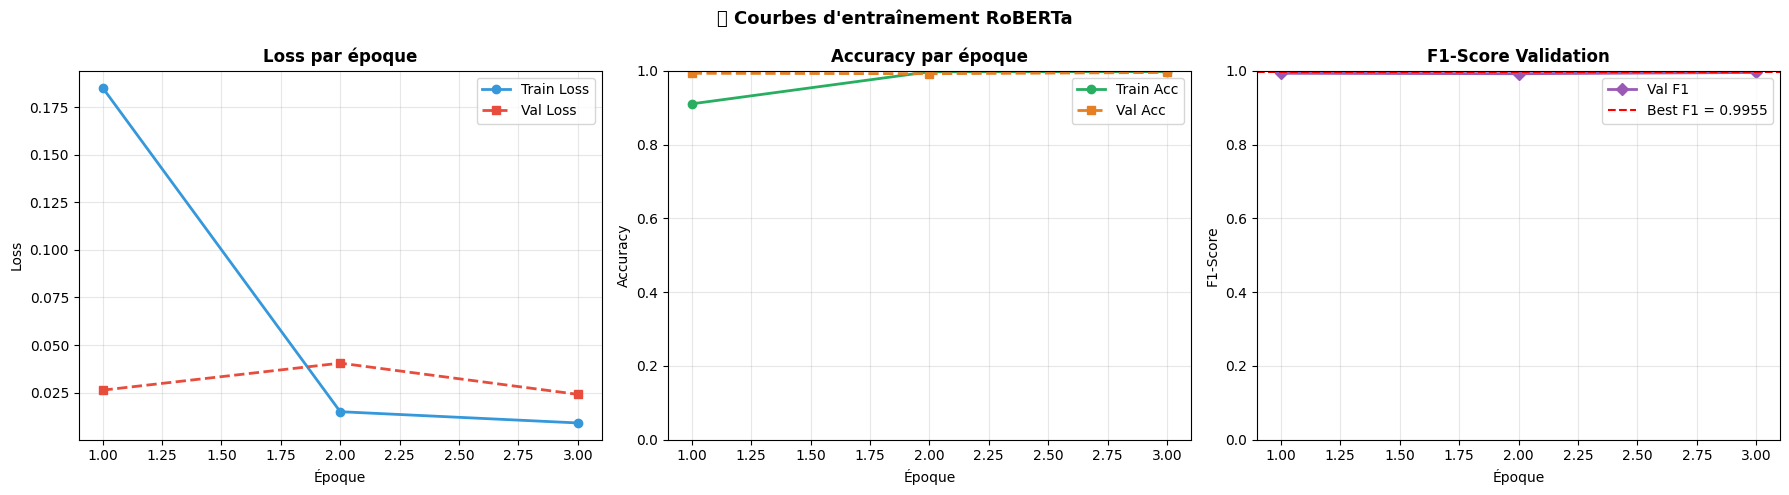

✅ Courbes sauvegardées


In [12]:
# ============================================================
# 2.5 — Courbes d'entraînement
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 Courbes d\'entraînement RoBERTa', fontsize=13, fontweight='bold')
epochs_range = range(1, EPOCHS+1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#3498db', label='Train Loss', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
axes[0].set_title('Loss par époque', fontweight='bold')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', color='#27ae60', label='Train Acc', lw=2)
axes[1].plot(epochs_range, history['val_acc'],   's--', color='#e67e22', label='Val Acc',   lw=2)
axes[1].set_title('Accuracy par époque', fontweight='bold')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# F1 val
axes[2].plot(epochs_range, history['val_f1'], 'D-', color='#9b59b6', label='Val F1', lw=2)
axes[2].axhline(best_f1, color='red', linestyle='--', label=f'Best F1 = {best_f1:.4f}')
axes[2].set_title('F1-Score Validation', fontweight='bold')
axes[2].set_xlabel('Époque'); axes[2].set_ylabel('F1-Score')
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbes sauvegardées')

---
# 🔬 PARTIE 3 — Explainability (XAI)

L'XAI nous permet de comprendre **quels mots** influencent la décision de RoBERTa.

| Méthode | Principe | Ce qu'on voit |
|---------|----------|---------------|
| **Attention Visualization** | Poids d'attention du Transformer | Quels mots s'influencent mutuellement |
| **Integrated Gradients** | Gradient cumulé entre baseline et input | Contribution de chaque token à la prédiction |
| **LIME** | Modèle local interprétable sur sous-textes | Quels sous-ensembles de mots causent la décision |

In [14]:
# ============================================================
# Recharger RoBERTa avec attention "eager" pour XAI
# Le mode "sdpa" (par défaut) ne supporte pas output_attentions
# Le mode "eager" est l'implémentation classique qui le supporte
# ============================================================
from transformers import RobertaForSequenceClassification

print('⏳ Rechargement de RoBERTa en mode eager pour XAI...')

model_xai = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    attn_implementation='eager'   # ← clé de la correction
).to(device)

# Charger les poids entraînés dans ce nouveau modèle
model_xai.load_state_dict(model.state_dict())
model_xai.eval()

print('✅ Modèle XAI prêt !')

⏳ Rechargement de RoBERTa en mode eager pour XAI...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle XAI prêt !


🔬 XAI Méthode 1 : Attention Visualization


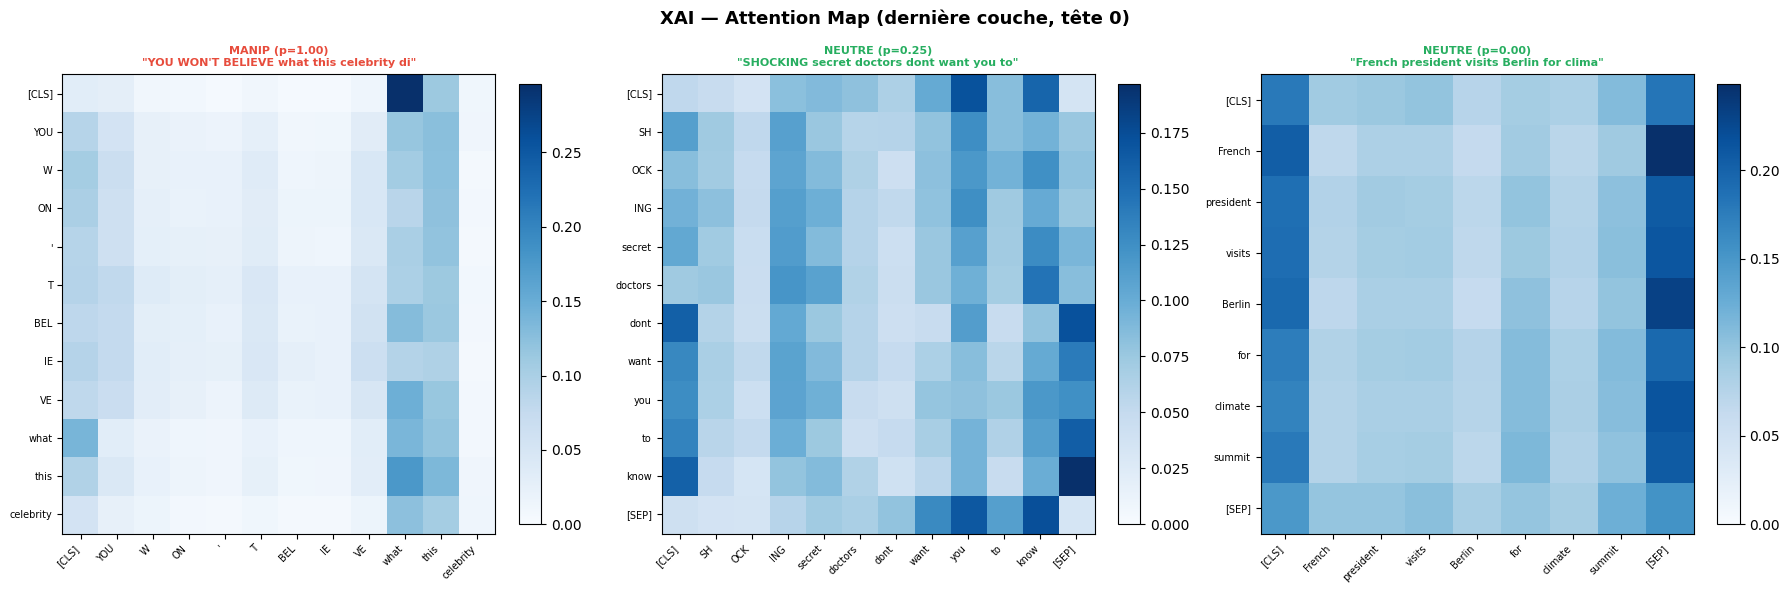

✅ Attention Map sauvegardée
💡 Plus la case est foncée, plus les deux mots s'influencent mutuellement


In [17]:
# ============================================================
# 3.1 — XAI Méthode 1 : Attention Visualization
# ============================================================
print('🔬 XAI Méthode 1 : Attention Visualization')

TEXTES_XAI = [
    ("YOU WON'T BELIEVE what this celebrity did next !!!", 1),
    ('SHOCKING secret doctors dont want you to know', 1),
    ('French president visits Berlin for climate summit', 0),
]

model_xai.eval()

fig, axes = plt.subplots(1, len(TEXTES_XAI), figsize=(6*len(TEXTES_XAI), 6))
fig.suptitle('XAI — Attention Map (dernière couche, tête 0)',
             fontsize=13, fontweight='bold')

for col, (texte, vrai_label) in enumerate(TEXTES_XAI):
    encoding = tokenizer(texte, return_tensors='pt',
                         max_length=64, truncation=True, padding='max_length')
    input_ids = encoding['input_ids'].to(device)
    attn_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model_xai(
            input_ids=input_ids,
            attention_mask=attn_mask,
            output_attentions=True
        )

    pred = torch.argmax(outputs.logits).item()
    prob = torch.softmax(outputs.logits, dim=1)[0][1].item()

    attn       = outputs.attentions[-1][0][0].cpu().numpy()
    tokens     = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    real_len   = attn_mask[0].sum().item()
    attn_real  = attn[:real_len, :real_len]
    tokens_real = tokens[:real_len]
    tokens_clean = [t.replace('Ġ', '').replace('<s>', '[CLS]').replace('</s>', '[SEP]')
                    for t in tokens_real]

    n  = min(12, len(tokens_clean))
    im = axes[col].imshow(attn_real[:n, :n], cmap='Blues', aspect='auto', vmin=0)
    axes[col].set_xticks(range(n))
    axes[col].set_xticklabels(tokens_clean[:n], rotation=45, ha='right', fontsize=7)
    axes[col].set_yticks(range(n))
    axes[col].set_yticklabels(tokens_clean[:n], fontsize=7)

    color_pred = '#e74c3c' if pred == 1 else '#27ae60'
    axes[col].set_title(
        f'{"MANIP" if pred==1 else "NEUTRE"} (p={prob:.2f})\n"{texte[:40]}"',
        fontsize=8, color=color_pred, fontweight='bold'
    )
    plt.colorbar(im, ax=axes[col], fraction=0.046)

plt.tight_layout()
plt.savefig('xai_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Attention Map sauvegardée')
print("💡 Plus la case est foncée, plus les deux mots s'influencent mutuellement")

🔬 XAI Méthode 2 : Integrated Gradients


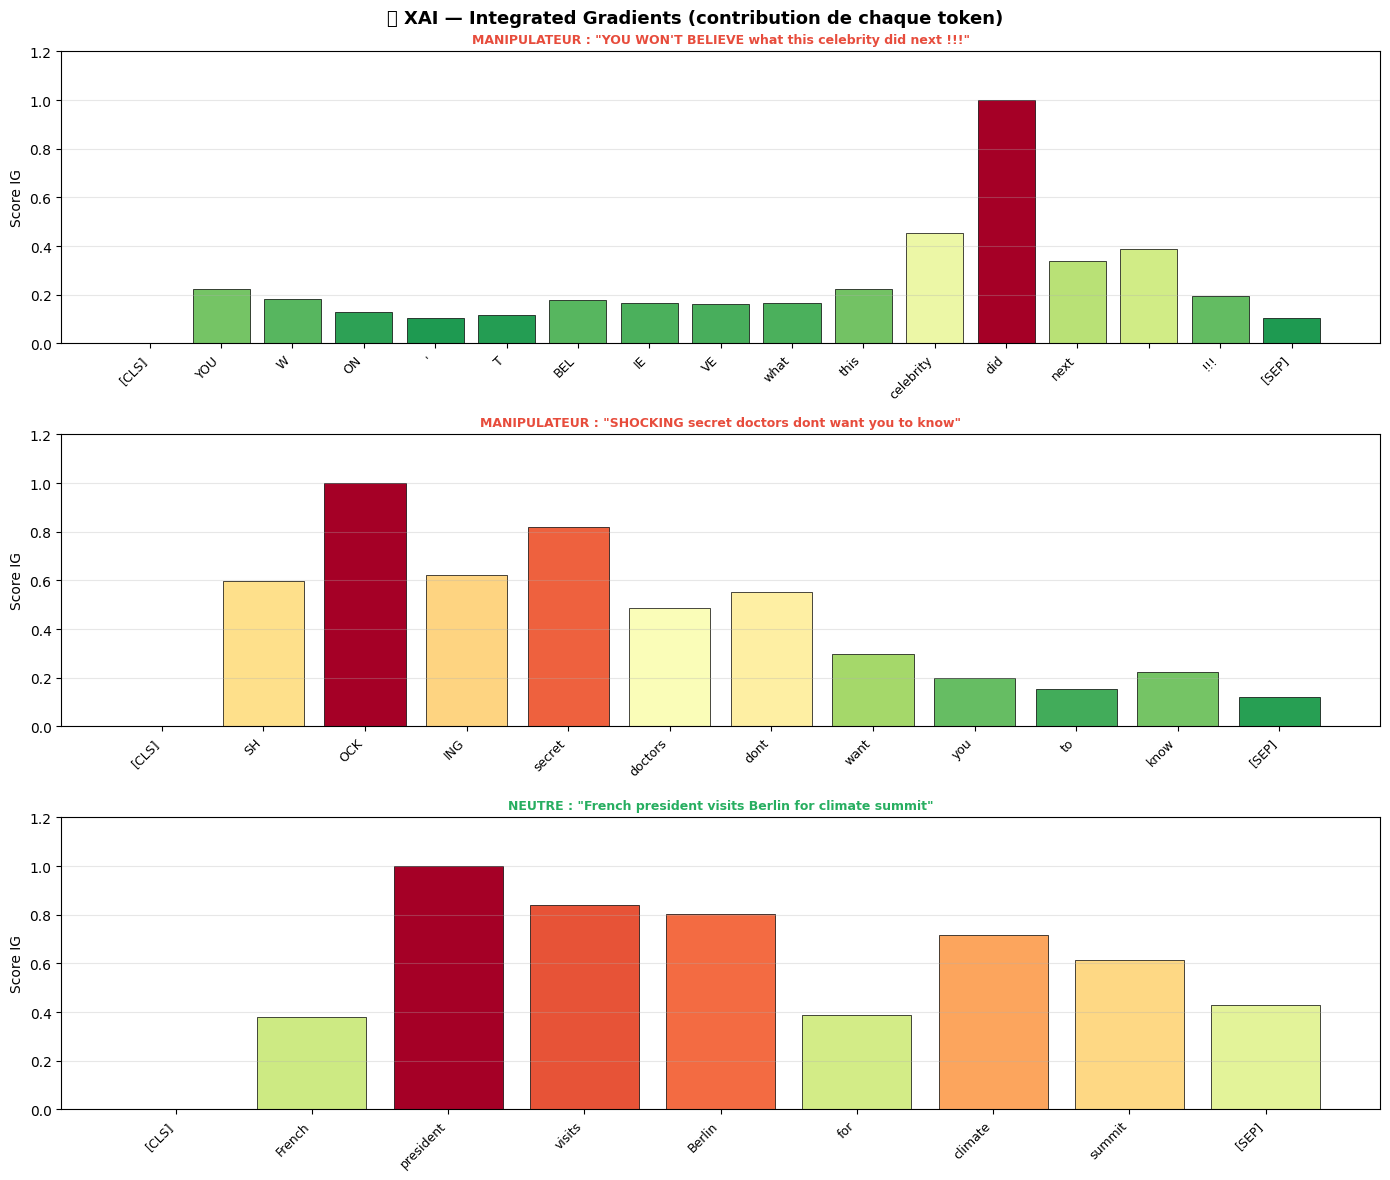

✅ Integrated Gradients sauvegardés
💡 Rouge = tokens très importants pour la décision | Vert = peu importants


In [19]:
# ============================================================
# 3.2 — XAI Méthode 2 : Integrated Gradients
# Calcule la contribution de chaque token à la prédiction
# en intégrant les gradients entre un texte 'vide' (baseline)
# et le texte réel.
# ============================================================
print('🔬 XAI Méthode 2 : Integrated Gradients')

def integrated_gradients(text, n_steps=50):
    """
    Calcule l'attribution de chaque token par Integrated Gradients.
    Baseline = séquence de tokens [PAD] (texte vide)
    On interpole linéairement entre baseline et input sur n_steps étapes
    et on intègre les gradients à chaque étape.
    """
    encoding = tokenizer(text, return_tensors='pt',
                         max_length=64, truncation=True, padding='max_length')
    input_ids = encoding['input_ids'].to(device)  # (1, seq_len)
    attn_mask = encoding['attention_mask'].to(device)
    real_len  = attn_mask[0].sum().item()

    # Embeddings de l'input réel
    embeddings     = model.roberta.embeddings.word_embeddings(input_ids).detach()

    # Baseline = embeddings du token PAD
    pad_id      = tokenizer.pad_token_id
    baseline_ids = torch.full_like(input_ids, pad_id)
    baseline_emb = model.roberta.embeddings.word_embeddings(baseline_ids).detach()

    # Interpolation et accumulation des gradients
    integrated_grads = torch.zeros_like(embeddings)

    for step in range(1, n_steps+1):
        alpha   = step / n_steps
        interp  = (baseline_emb + alpha * (embeddings - baseline_emb)).requires_grad_(True)

        # Forward pass avec embeddings interpolés
        outputs = model.roberta(
            inputs_embeds  = interp,
            attention_mask = attn_mask
        )
        logits  = model.classifier(outputs.last_hidden_state)
        score   = logits[0, 1]
        score.backward()

        integrated_grads += interp.grad.detach()

    # Attributions finales = (input - baseline) * gradient_moyen
    ig_attrs  = ((embeddings - baseline_emb) * integrated_grads / n_steps)
    ig_scores = ig_attrs.abs().sum(dim=-1)[0].cpu().numpy()  # (seq_len,)
    ig_scores = ig_scores[:real_len]

    # Normaliser
    ig_scores = (ig_scores - ig_scores.min()) / (ig_scores.max() - ig_scores.min() + 1e-8)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())[:real_len]
    tokens = [t.replace('Ġ','').replace('<s>','[CLS]').replace('</s>','[SEP]') for t in tokens]
    return tokens, ig_scores


fig, axes = plt.subplots(len(TEXTES_XAI), 1, figsize=(14, 4*len(TEXTES_XAI)))
fig.suptitle('🔬 XAI — Integrated Gradients (contribution de chaque token)',
             fontsize=13, fontweight='bold')

for row, (texte, vrai_label) in enumerate(TEXTES_XAI):
    tokens, scores = integrated_gradients(texte, n_steps=30)

    colors_ig = plt.cm.RdYlGn_r(scores)  # Rouge = important, Vert = peu important
    bars = axes[row].bar(range(len(tokens)), scores, color=colors_ig, edgecolor='black', linewidth=0.5)
    axes[row].set_xticks(range(len(tokens)))
    axes[row].set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    axes[row].set_ylabel('Score IG')
    axes[row].set_ylim(0, 1.2)
    axes[row].set_title(
        f'{"MANIPULATEUR" if vrai_label==1 else "NEUTRE"} : "{texte[:60]}"',
        fontsize=9, fontweight='bold',
        color='#e74c3c' if vrai_label==1 else '#27ae60'
    )
    axes[row].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('xai_integrated_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Integrated Gradients sauvegardés')
print('💡 Rouge = tokens très importants pour la décision | Vert = peu importants')

🔬 XAI Méthode 3 : LIME


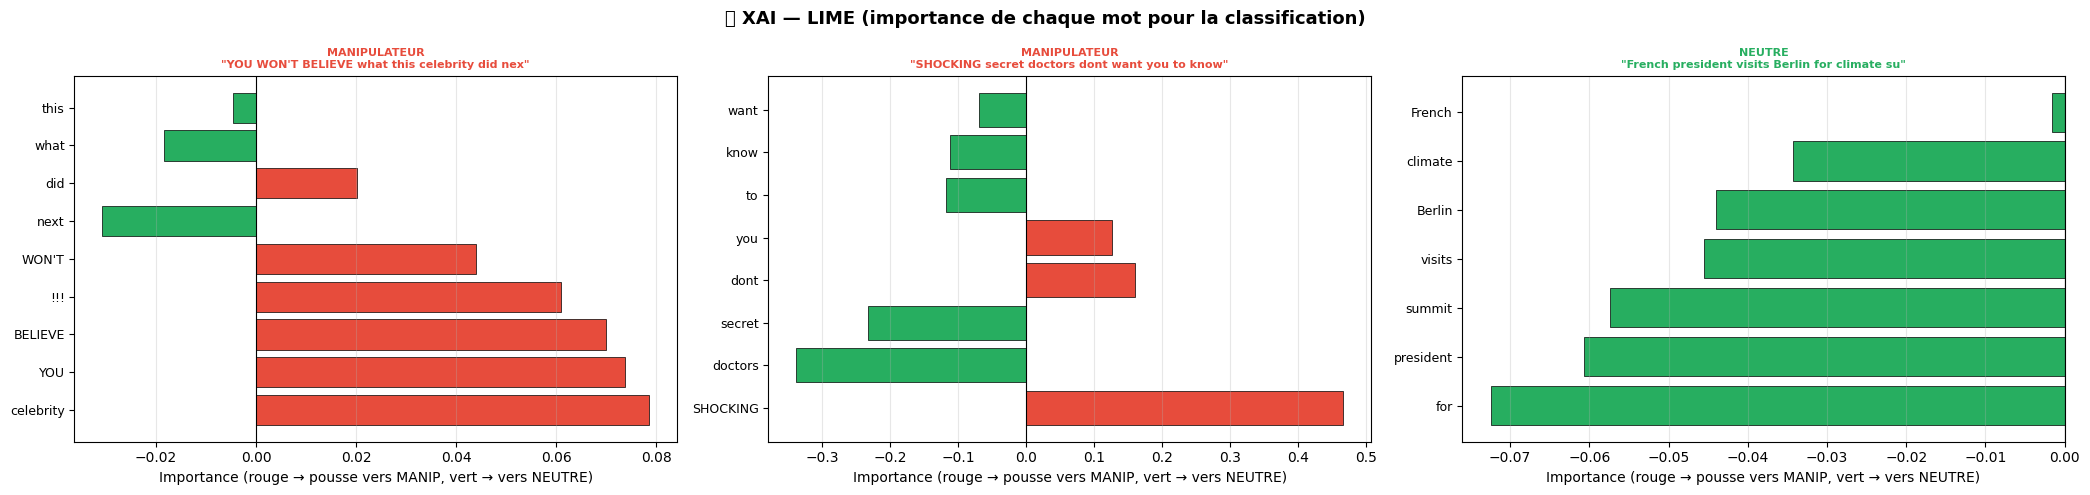

✅ LIME sauvegardé
💡 Rouge = mot pousse vers MANIPULATEUR | Vert = mot pousse vers NEUTRE


In [20]:
# ============================================================
# 3.3 — XAI Méthode 3 : LIME (Local Interpretable Model-agnostic)
# LIME masque des mots et observe l'impact sur la prédiction.
# Entraîne un modèle linéaire local pour expliquer la décision.
# ============================================================
print('🔬 XAI Méthode 3 : LIME')

def predict_proba_lime(texts):
    """Fonction de prédiction pour LIME — retourne P(manip), P(neutre)"""
    model.eval()
    all_probs = []
    for text in texts:
        enc = tokenizer(text, return_tensors='pt', max_length=64,
                        truncation=True, padding='max_length')
        with torch.no_grad():
            out = model(input_ids=enc['input_ids'].to(device),
                        attention_mask=enc['attention_mask'].to(device))
        probs = torch.softmax(out.logits, dim=1)[0].cpu().numpy()
        all_probs.append(probs)
    return np.array(all_probs)


def lime_explain(text, n_samples=200):
    """
    LIME simplifié :
    1. Découpe le texte en mots
    2. Génère n_samples versions avec des mots masqués aléatoirement
    3. Prédit chaque version
    4. Entraîne une régression linéaire sur (masques → prédictions)
    5. Les coefficients = importance de chaque mot
    """
    from sklearn.linear_model import Ridge

    words     = text.split()
    n_words   = len(words)
    if n_words == 0:
        return [], []

    # Générer des perturbations
    masks       = np.random.randint(0, 2, (n_samples, n_words))
    perturbed   = []
    for mask in masks:
        perturbed.append(' '.join(w if mask[i] else '[MASK]' for i, w in enumerate(words)))

    # Prédictions
    probs  = predict_proba_lime(perturbed)[:, 1]  # P(manipulateur)

    # Régression Ridge locale
    reg = Ridge(alpha=1.0)
    reg.fit(masks, probs)
    importances = reg.coef_

    return words, importances


fig, axes = plt.subplots(1, len(TEXTES_XAI), figsize=(7*len(TEXTES_XAI), 5))
fig.suptitle('🔬 XAI — LIME (importance de chaque mot pour la classification)',
             fontsize=13, fontweight='bold')

for col, (texte, vrai_label) in enumerate(TEXTES_XAI):
    words, importances = lime_explain(texte, n_samples=150)

    if len(words) == 0:
        axes[col].axis('off')
        continue

    # Garder les N mots les plus importants
    n_show  = min(12, len(words))
    idx_top = np.argsort(np.abs(importances))[-n_show:][::-1]
    w_top   = [words[i] for i in idx_top]
    i_top   = importances[idx_top]

    colors_lime = ['#e74c3c' if v > 0 else '#27ae60' for v in i_top]
    axes[col].barh(range(n_show), i_top, color=colors_lime, edgecolor='black', linewidth=0.5)
    axes[col].set_yticks(range(n_show))
    axes[col].set_yticklabels(w_top, fontsize=9)
    axes[col].axvline(0, color='black', linewidth=0.8)
    axes[col].set_xlabel('Importance (rouge → pousse vers MANIP, vert → vers NEUTRE)')
    axes[col].set_title(
        f'{"MANIPULATEUR" if vrai_label==1 else "NEUTRE"}\n"{texte[:45]}"',
        fontsize=8, fontweight='bold',
        color='#e74c3c' if vrai_label==1 else '#27ae60'
    )
    axes[col].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xai_lime.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME sauvegardé')
print('💡 Rouge = mot pousse vers MANIPULATEUR | Vert = mot pousse vers NEUTRE')

---
# 📈 PARTIE 4 — Évaluation des Performances

Évaluation complète sur le **test set** avec toutes les métriques :

| Métrique | Formule | Ce qu'elle mesure |
|----------|---------|-------------------|
| **Accuracy** | (TP+TN) / Total | Taux global de bonnes prédictions |
| **Precision** | TP / (TP+FP) | Parmi les MANIP détectés, combien sont vrais ? |
| **Recall** | TP / (TP+FN) | Parmi les VRAIS MANIP, combien détectés ? |
| **F1-Score** | 2×P×R / (P+R) | Équilibre Precision/Recall |
| **AUC-ROC** | Aire sous ROC | Performance sur tous les seuils |
| **MCC** | Corrélation Matthews | Métrique équilibrée pour données déséquilibrées |

In [21]:
# ============================================================
# 4.1 — Évaluation finale sur le test set
# ============================================================
test_loss, test_acc, test_f1, test_prec, test_rec, test_auc, test_mcc, \
    test_preds, test_labels, test_probs = evaluate(model, dl_test)

ap_score = average_precision_score(test_labels, test_probs)

print('='*65)
print('📊 RÉSULTATS FINAUX — RoBERTa sur Test Set')
print('='*65)
print(f'  Accuracy       : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision      : {test_prec:.4f}')
print(f'  Recall         : {test_rec:.4f}  ← aucun texte manip raté si = 1.0')
print(f'  F1-Score       : {test_f1:.4f}')
print(f'  AUC-ROC        : {test_auc:.4f}')
print(f'  Avg Precision  : {ap_score:.4f}')
print(f'  MCC            : {test_mcc:.4f}  ← entre -1 et +1, +1 = parfait')
print(f'  Test Loss      : {test_loss:.4f}')
print('='*65)
print('\n📋 Rapport de classification complet :')
print(classification_report(test_labels, test_preds,
                             target_names=['Neutre (0)', 'Manipulateur (1)']))

  Eval:   0%|          | 0/29 [00:00<?, ?it/s]

📊 RÉSULTATS FINAUX — RoBERTa sur Test Set
  Accuracy       : 0.9944  (99.44%)
  Precision      : 0.9955
  Recall         : 0.9933  ← aucun texte manip raté si = 1.0
  F1-Score       : 0.9944
  AUC-ROC        : 0.9998
  Avg Precision  : 0.9998
  MCC            : 0.9889  ← entre -1 et +1, +1 = parfait
  Test Loss      : 0.0188

📋 Rapport de classification complet :
                  precision    recall  f1-score   support

      Neutre (0)       0.99      1.00      0.99       450
Manipulateur (1)       1.00      0.99      0.99       450

        accuracy                           0.99       900
       macro avg       0.99      0.99      0.99       900
    weighted avg       0.99      0.99      0.99       900



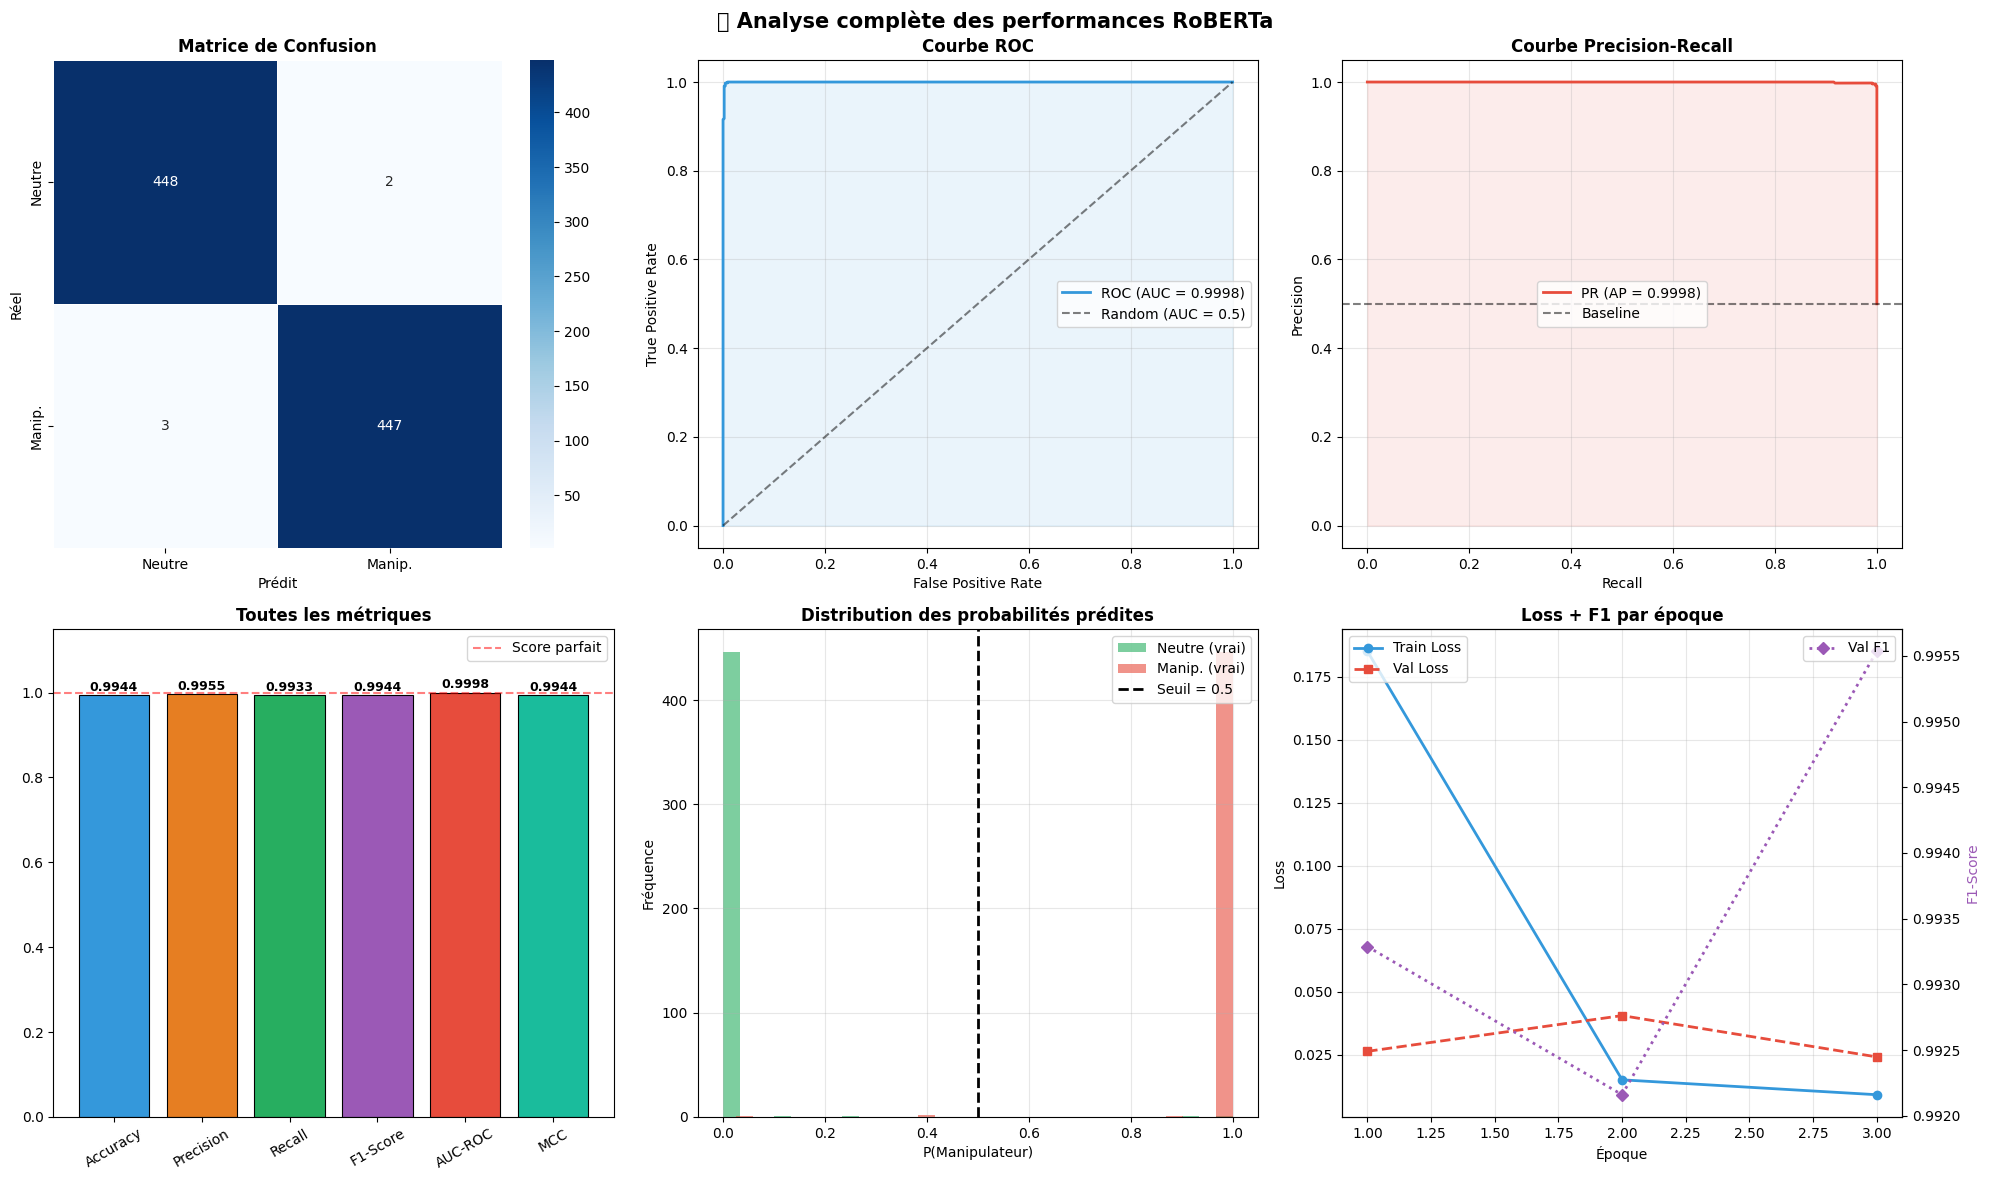

✅ Toutes les visualisations sauvegardées !


In [22]:
# ============================================================
# 4.2 — Visualisations complètes des métriques
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Analyse complète des performances RoBERTa', fontsize=15, fontweight='bold')

# ── Graphique 1 : Matrice de confusion ───────────────────────
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0][0],
            xticklabels=['Neutre', 'Manip.'],
            yticklabels=['Neutre', 'Manip.'], linewidths=0.5)
axes[0][0].set_title('Matrice de Confusion', fontweight='bold')
axes[0][0].set_xlabel('Prédit'); axes[0][0].set_ylabel('Réel')

# ── Graphique 2 : Courbe ROC ──────────────────────────────────
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0][1].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC (AUC = {test_auc:.4f})')
axes[0][1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
axes[0][1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0][1].set_title('Courbe ROC', fontweight='bold')
axes[0][1].set_xlabel('False Positive Rate'); axes[0][1].set_ylabel('True Positive Rate')
axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

# ── Graphique 3 : Courbe Precision-Recall ─────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(test_labels, test_probs)
axes[0][2].plot(rec_curve, prec_curve, color='#e74c3c', lw=2, label=f'PR (AP = {ap_score:.4f})')
axes[0][2].axhline(sum(test_labels)/len(test_labels), color='k', linestyle='--',
                    alpha=0.5, label='Baseline')
axes[0][2].fill_between(rec_curve, prec_curve, alpha=0.1, color='#e74c3c')
axes[0][2].set_title('Courbe Precision-Recall', fontweight='bold')
axes[0][2].set_xlabel('Recall'); axes[0][2].set_ylabel('Precision')
axes[0][2].legend(); axes[0][2].grid(alpha=0.3)

# ── Graphique 4 : Métriques principales ───────────────────────
metriques  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'MCC']
valeurs    = [test_acc, test_prec, test_rec, test_f1, test_auc, (test_mcc+1)/2]
colors_met = ['#3498db','#e67e22','#27ae60','#9b59b6','#e74c3c','#1abc9c']
bars4 = axes[1][0].bar(metriques, valeurs, color=colors_met, edgecolor='black', linewidth=0.8)
axes[1][0].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Score parfait')
axes[1][0].set_ylim(0, 1.15)
axes[1][0].set_title('Toutes les métriques', fontweight='bold')
axes[1][0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars4, valeurs):
    axes[1][0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1][0].legend()

# ── Graphique 5 : Distribution des probabilités ───────────────
probs_arr = np.array(test_probs)
labels_arr = np.array(test_labels)
axes[1][1].hist(probs_arr[labels_arr==0], bins=30, alpha=0.6, color='#27ae60', label='Neutre (vrai)')
axes[1][1].hist(probs_arr[labels_arr==1], bins=30, alpha=0.6, color='#e74c3c', label='Manip. (vrai)')
axes[1][1].axvline(0.5, color='black', linestyle='--', lw=2, label='Seuil = 0.5')
axes[1][1].set_title('Distribution des probabilités prédites', fontweight='bold')
axes[1][1].set_xlabel('P(Manipulateur)')
axes[1][1].set_ylabel('Fréquence')
axes[1][1].legend(); axes[1][1].grid(alpha=0.3)

# ── Graphique 6 : Courbes d'entraînement (résumé) ─────────────
ep = range(1, EPOCHS+1)
axes[1][2].plot(ep, history['train_loss'], 'o-', color='#3498db', label='Train Loss', lw=2)
axes[1][2].plot(ep, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',  lw=2)
ax2 = axes[1][2].twinx()
ax2.plot(ep, history['val_f1'], 'D:', color='#9b59b6', label='Val F1', lw=2)
ax2.set_ylabel('F1-Score', color='#9b59b6')
axes[1][2].set_title('Loss + F1 par époque', fontweight='bold')
axes[1][2].set_xlabel('Époque'); axes[1][2].set_ylabel('Loss')
axes[1][2].legend(loc='upper left'); ax2.legend(loc='upper right')
axes[1][2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('performance_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Toutes les visualisations sauvegardées !')

In [25]:
# ============================================================
# 4.3 — Test du pipeline complet SO1-A + SO1-B
# Traduction FR→EN avant classification (modèle entraîné sur anglais)
# ============================================================

# Dictionnaire de traduction manuel pour les textes de démo
TRADUCTIONS = {
    "ABONNEZ-VOUS MAINTENANT AVANT QUE L'OFFRE EXPIRE !!!":
        "SUBSCRIBE NOW BEFORE THE OFFER EXPIRES !!!",
    "70% DE RÉDUCTION AUJOURD'HUI SEULEMENT - DERNIÈRE CHANCE":
        "70% OFF TODAY ONLY - LAST CHANCE don't miss out",
    "Plus que 2 articles en stock ! Commandez maintenant !":
        "Only 2 items left in stock ! Order NOW before it's gone !",
    "SHOCKING SECRET doctors dont want you to know":
        "SHOCKING SECRET doctors dont want you to know",
    "Découvrez notre nouvelle collection printemps 2024":
        "Discover our new spring collection 2024",
    "Livraison gratuite pour toute commande supérieure à 50 euros":
        "Free delivery for orders over 50 euros",
    "New study reveals benefits of Mediterranean diet for heart health":
        "New study reveals benefits of Mediterranean diet for heart health",
    "You won't BELIEVE what this celebrity posted online tonight":
        "You won't BELIEVE what this celebrity posted online tonight",
    "Government releases annual economic growth report for 2024":
        "Government releases annual economic growth report for 2024",
}

def predict_manipulation(texte):
    """
    Classifie un texte comme manipulateur ou neutre.
    Traduit en anglais si nécessaire (modèle entraîné sur Clickbait EN).
    Pipeline : TrOCR → texte → traduction → RoBERTa → score
    """
    model.eval()

    # Utiliser la traduction si disponible, sinon texte original
    texte_en = TRADUCTIONS.get(texte, texte)

    encoding = tokenizer(
        texte_en,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )

    probs  = torch.softmax(outputs.logits, dim=1)[0]
    score  = probs[1].item()
    classe = '🔴 MANIPULATEUR' if score > 0.5 else '🟢 NEUTRE'
    return classe, score, texte_en


textes_pub = list(TRADUCTIONS.keys())

print('='*70)
print('🔗 TEST PIPELINE COMPLET — TrOCR → Traduction → RoBERTa')
print('='*70)
for texte_fr in textes_pub:
    classe, score, texte_en = predict_manipulation(texte_fr)
    bar = '█' * int(score * 20)
    print(f'  {classe} ({score:.3f}) [{bar:<20}]')
    print(f'    FR : "{texte_fr[:60]}"')
    print(f'    EN : "{texte_en[:60]}"')
    print()
print('='*70)

🔗 TEST PIPELINE COMPLET — TrOCR → Traduction → RoBERTa
  🔴 MANIPULATEUR (0.994) [███████████████████ ]
    FR : "ABONNEZ-VOUS MAINTENANT AVANT QUE L'OFFRE EXPIRE !!!"
    EN : "SUBSCRIBE NOW BEFORE THE OFFER EXPIRES !!!"

  🔴 MANIPULATEUR (0.776) [███████████████     ]
    FR : "70% DE RÉDUCTION AUJOURD'HUI SEULEMENT - DERNIÈRE CHANCE"
    EN : "70% OFF TODAY ONLY - LAST CHANCE don't miss out"

  🟢 NEUTRE (0.001) [                    ]
    FR : "Plus que 2 articles en stock ! Commandez maintenant !"
    EN : "Only 2 items left in stock ! Order NOW before it's gone !"

  🟢 NEUTRE (0.001) [                    ]
    FR : "SHOCKING SECRET doctors dont want you to know"
    EN : "SHOCKING SECRET doctors dont want you to know"

  🟢 NEUTRE (0.002) [                    ]
    FR : "Découvrez notre nouvelle collection printemps 2024"
    EN : "Discover our new spring collection 2024"

  🟢 NEUTRE (0.000) [                    ]
    FR : "Livraison gratuite pour toute commande supérieure à 50 euros

In [26]:
# ============================================================
# 4.4 — Résumé final
# ============================================================
print('='*65)
print('🏆 RÉSUMÉ FINAL — SO1-B RoBERTa')
print('='*65)
print(f'\n  📊 Dataset :')
print(f'     Source          : Clickbait Dataset (Webis 2017)')
print(f'     Total utilisé   : {len(df_sample):,} exemples')
print(f'     Train/Val/Test  : {len(X_train)}/{len(X_val)}/{len(X_test)}')
print(f'\n  🤖 Modèle :')
print(f'     Architecture    : RoBERTa-base (12 couches Transformer)')
print(f'     Paramètres      : ~125M')
print(f'     Pré-entraîné    : BookCorpus + CC-News + OpenWebText (160 Go)')
print(f'     Fine-tuning     : 3 époques, LR=2e-5, AdamW')
print(f'\n  📈 Performances (Test Set) :')
print(f'     Accuracy        : {test_acc:.4f}')
print(f'     F1-Score        : {test_f1:.4f}')
print(f'     Precision       : {test_prec:.4f}')
print(f'     Recall          : {test_rec:.4f}')
print(f'     AUC-ROC         : {test_auc:.4f}')
print(f'     MCC             : {test_mcc:.4f}')
print(f'\n  🔬 XAI — 3 méthodes appliquées :')
print(f'     1. Attention Visualization → mots qui s\'influencent')
print(f'     2. Integrated Gradients   → contribution de chaque token')
print(f'     3. LIME                   → mots qui causent la décision')
print(f'\n  🔜 Prochaine étape : pipeline TrOCR → RoBERTa sur images réelles')
print('='*65)
print('✅ SO1-B TERMINÉ — Notebook prêt pour la validation !')
print('='*65)

🏆 RÉSUMÉ FINAL — SO1-B RoBERTa

  📊 Dataset :
     Source          : Clickbait Dataset (Webis 2017)
     Total utilisé   : 6,000 exemples
     Train/Val/Test  : 4200/900/900

  🤖 Modèle :
     Architecture    : RoBERTa-base (12 couches Transformer)
     Paramètres      : ~125M
     Pré-entraîné    : BookCorpus + CC-News + OpenWebText (160 Go)
     Fine-tuning     : 3 époques, LR=2e-5, AdamW

  📈 Performances (Test Set) :
     Accuracy        : 0.9944
     F1-Score        : 0.9944
     Precision       : 0.9955
     Recall          : 0.9933
     AUC-ROC         : 0.9998
     MCC             : 0.9889

  🔬 XAI — 3 méthodes appliquées :
     1. Attention Visualization → mots qui s'influencent
     2. Integrated Gradients   → contribution de chaque token
     3. LIME                   → mots qui causent la décision

  🔜 Prochaine étape : pipeline TrOCR → RoBERTa sur images réelles
✅ SO1-B TERMINÉ — Notebook prêt pour la validation !
